# Popularity Score: Review Count Distribution (v)

This notebook inspects our actual data to justify choosing **m = P60(v)**
for the IMDB-style weighted rating used in popularity scoring.


In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# Optional: use a Korean-capable font if available
def _set_korean_font() -> None:
    candidates = ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Malgun Gothic"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            break
    mpl.rcParams["axes.unicode_minus"] = False

_set_korean_font()


In [3]:
DATA_DIR = Path('../../data/embedding_json')
files = {
    'tourspot': DATA_DIR / 'embedding_tourspot.json',
    'cafe': DATA_DIR / 'embedding_cafe.json',
    'restaurant': DATA_DIR / 'embedding_restaurant.json',
}

def _load_review_counts(path: Path):
    data = json.loads(path.read_text(encoding='utf-8'))
    counts = []
    for obj in data:
        g = obj.get('google') if isinstance(obj.get('google'), dict) else {}
        v = g.get('user_ratings_total')
        if v is None:
            counts.append(None)
            continue
        try:
            v = float(v)
        except (TypeError, ValueError):
            v = None
        counts.append(v)
    return counts

counts_by_cat = {cat: _load_review_counts(path) for cat, path in files.items()}
counts_all = []
for cat_counts in counts_by_cat.values():
    counts_all.extend(cat_counts)

len(counts_all)


3157

In [4]:
def _summary_stats(values):
    total = len(values)
    arr = np.array([v for v in values if v is not None and np.isfinite(v) and v > 0], dtype=float)
    valid = len(arr)
    missing = total - valid
    if valid == 0:
        return {
            'total': total, 'valid': 0, 'missing': missing,
            'p50': None, 'p60': None, 'p70': None, 'p80': None, 'p90': None,
            'pct_v_le_2': None, 'pct_v_le_5': None
        }
    p50, p60, p70, p80, p90 = np.percentile(arr, [50, 60, 70, 80, 90])
    pct_v_le_2 = (arr <= 2).mean() * 100
    pct_v_le_5 = (arr <= 5).mean() * 100
    return {
        'total': total, 'valid': valid, 'missing': missing,
        'p50': p50, 'p60': p60, 'p70': p70, 'p80': p80, 'p90': p90,
        'pct_v_le_2': pct_v_le_2, 'pct_v_le_5': pct_v_le_5
    }

summaries = {cat: _summary_stats(vals) for cat, vals in counts_by_cat.items()}
summaries['overall'] = _summary_stats(counts_all)

for cat, s in summaries.items():
    print(f"[{cat}] total={s['total']}, valid={s['valid']}, missing={s['missing']}")
    if s['p60'] is not None:
        print(
            f"  P50={s['p50']:.0f}, P60={s['p60']:.0f}, P70={s['p70']:.0f}, P80={s['p80']:.0f}, P90={s['p90']:.0f}"
        )
        print(f"  v<=2: {s['pct_v_le_2']:.1f}%, v<=5: {s['pct_v_le_5']:.1f}%")


[tourspot] total=1205, valid=1130, missing=75
  P50=168, P60=303, P70=510, P80=965, P90=2728
  v<=2: 4.6%, v<=5: 11.9%
[cafe] total=640, valid=490, missing=150
  P50=36, P60=62, P70=110, P80=193, P90=457
  v<=2: 16.3%, v<=5: 26.9%
[restaurant] total=1312, valid=1072, missing=240
  P50=56, P60=104, P70=188, P80=341, P90=796
  v<=2: 14.5%, v<=5: 22.8%
[overall] total=3157, valid=2692, missing=465
  P50=79, P60=146, P70=264, P80=510, P90=1286
  v<=2: 10.7%, v<=5: 18.9%


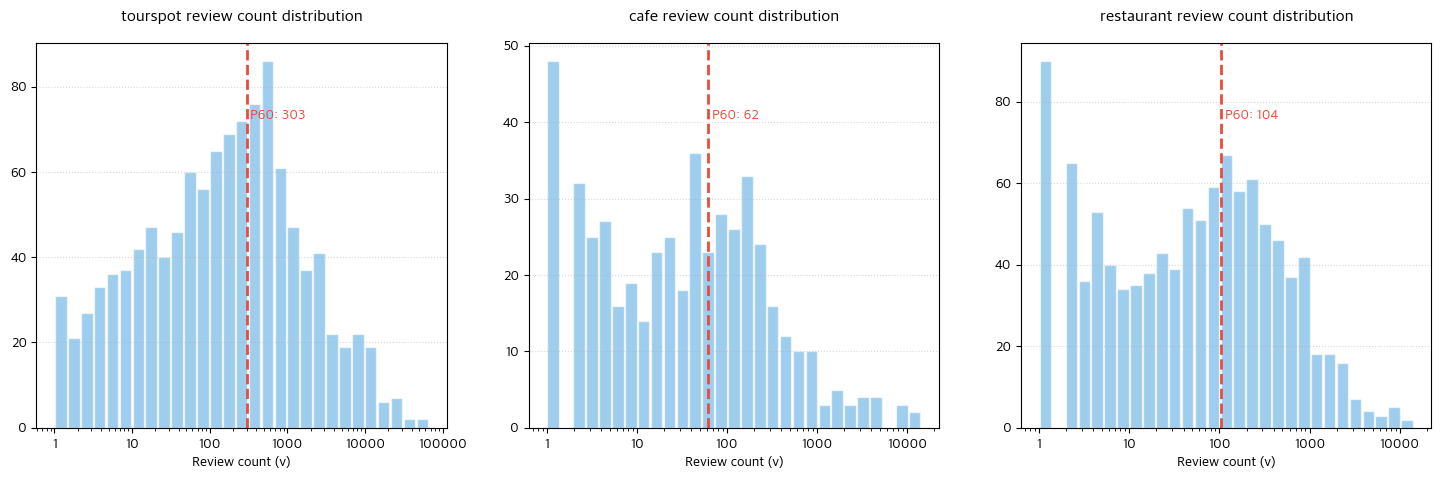

In [8]:
from matplotlib.ticker import ScalarFormatter

def _plot_distribution(values, title, ax):
    arr = np.array([v for v in values if v is not None and np.isfinite(v) and v > 0], dtype=float)
    if arr.size == 0:
        return

    p60 = np.percentile(arr, 60)

    bins = np.logspace(0, np.log10(arr.max()), 30)
    ax.hist(arr, bins=bins, alpha=0.6, color='#5DADE2', rwidth=0.9, edgecolor='white')

    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter())

    ax.axvline(p60, color='#E74C3C', linestyle='--', linewidth=2)
    ax.text(p60 * 1.1, ax.get_ylim()[1] * 0.8, f'P60: {p60:.0f}', color='#E74C3C', fontweight='bold')

    ax.set_title(title, fontsize=12, pad=15)
    ax.set_xlabel('Review count (v)')
    ax.grid(axis='y', linestyle=':', alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (cat, vals) in zip(axes, counts_by_cat.items()):
    _plot_distribution(vals, f'{cat} review count distribution', ax)
plt.show()



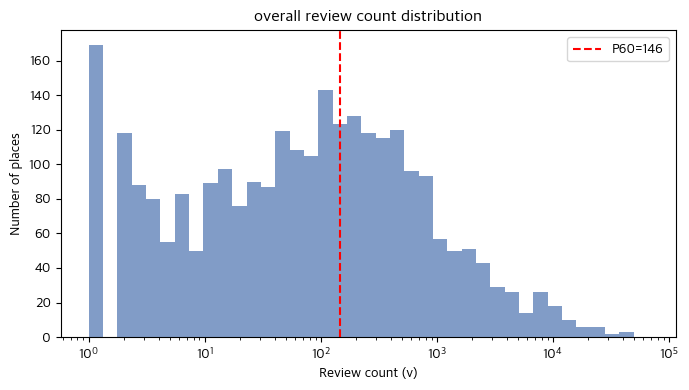

In [6]:
# Combined distribution (all categories)
plt.figure(figsize=(7, 4))
_plot_distribution(counts_all, 'overall review count distribution')
plt.show()
